# Central Limit Theorem Simulation with Exponential Distribution

## Objective
Demonstrate the Central Limit Theorem by examining how the sampling distribution
of means approaches normality as sample size increases, even when sampling from
a highly skewed exponential distribution.

## Problem Statement
**Part (a):** Generate 1500 random samples of size n = 10 from an exponential
distribution with mean = 2 and standard deviation = 2. Calculate the sample
mean for each sample and draw a relative frequency histogram.

**Part (b):** Repeat part (a) with n = 50 and n = 100, and draw conclusions
about the behavior of the sampling distribution.

---

In [21]:
# Install packages if needed (uncomment if running for the first time)
install.packages("ggplot2")
install.packages("gridExtra")
install.packages("dplyr")

# Load required libraries
library(ggplot2)
library(gridExtra)
library(dplyr)

cat("✓ All libraries loaded successfully!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



✓ All libraries loaded successfully!


## Simulation Parameters

### Population Distribution
- **Distribution:** Exponential
- **Mean (μ):** 2
- **Standard Deviation (σ):** 2
- **Rate parameter (λ):** 1/2 = 0.5

### Simulation Settings
- **Number of samples:** 1,500 for each sample size
- **Sample sizes to test:** n = 10, 50, 100

### Key Theoretical Prediction
According to the Central Limit Theorem, the sampling distribution of means
should have:
- Mean = μ = 2
- Standard Error = σ/√n

---

In [22]:
set.seed(42)

#P parameters
POPULATION_MEAN <- 2
POPULATION_SD <- 2

#rate params for e distribution
#exponential: mean = 1/lambda, so lambda = 1/mean
RATE_PARAMETER <- 1 / POPULATION_MEAN

# Simulation params
N_SAMPLES <- 1500
SAMPLE_SIZES <- c(10, 50, 100)

cat("Configuration:\n")
cat(sprintf("  Population Mean: %.2f\n", POPULATION_MEAN))
cat(sprintf("  Population SD: %.2f\n", POPULATION_SD))
cat(sprintf("  Rate Parameter (λ): %.2f\n", RATE_PARAMETER))
cat(sprintf("  Number of Samples: %d\n", N_SAMPLES))
cat(sprintf("  Sample Sizes: %s\n", paste(SAMPLE_SIZES, collapse = ", ")))

Configuration:
  Population Mean: 2.00
  Population SD: 2.00
  Rate Parameter (λ): 0.50
  Number of Samples: 1500
  Sample Sizes: 10, 50, 100


## Core Functions

We'll define three main functions:

1. **`generate_sample_means()`** - Efficiently generates multiple samples and
   calculates their means using matrix operations
   
2. **`calculate_summary_stats()`** - Computes descriptive statistics for the
   sampling distribution
   
3. **`create_histogram()`** - Creates professional visualizations with:
   - Relative frequency histogram
   - Theoretical normal distribution overlay
   - Population mean reference line

---

In [23]:
#' Generate Sample Means from Exponential Distribution
#'
#' @param n_samples Integer. Number of samples to generate
#' @param sample_size Integer. Size of each sample
#' @param rate Numeric. Rate parameter for exponential distribution
#' @return Numeric vector of sample means
generate_sample_means <- function(n_samples, sample_size, rate) {
  # Generate matrix: each row is a sample
  sample_matrix <- matrix(
    rexp(n_samples * sample_size, rate = rate),
    nrow = n_samples,
    ncol = sample_size
  )

  # Calculate mean of each sample (row)
  sample_means <- rowMeans(sample_matrix)

  return(sample_means)
}

#' Calculate Summary Statistics
#'
#' @param x Numeric vector
#' @return Named list of summary statistics
calculate_summary_stats <- function(x) {
  list(
    mean = mean(x),
    sd = sd(x),
    median = median(x),
    min = min(x),
    max = max(x),
    q25 = quantile(x, 0.25),
    q75 = quantile(x, 0.75)
  )
}

#' Create Professional Histogram with Normal Overlay
#'
#' @param data Numeric vector of sample means
#' @param sample_size Integer. Size of each sample
#' @param population_mean Numeric. True population mean
#' @param population_sd Numeric. True population standard deviation
#' @return ggplot object
create_histogram <- function(data, sample_size, population_mean, population_sd) {
  # Calculate theoretical standard error
  theoretical_se <- population_sd / sqrt(sample_size)

  # Create data frame for plotting
  df <- data.frame(sample_means = data)

  # Calculate histogram breaks
  n_bins <- 30

  # Create the plot
  p <- ggplot(df, aes(x = sample_means)) +
    # Histogram with relative frequency
    geom_histogram(
      aes(y = after_stat(density)),
      bins = n_bins,
      fill = "#4A90E2",
      color = "white",
      alpha = 0.7
    ) +
    # Overlay theoretical normal distribution
    stat_function(
      fun = dnorm,
      args = list(mean = population_mean, sd = theoretical_se),
      color = "#E74C3C",
      linewidth = 1.2,
      linetype = "solid"
    ) +
    # Add vertical line at population mean
    geom_vline(
      xintercept = population_mean,
      color = "#27AE60",
      linetype = "dashed",
      linewidth = 1
    ) +
    # Labels and theme
    labs(
      title = sprintf("Sampling Distribution of Mean (n = %d)", sample_size),
      subtitle = sprintf(
        "Mean = %.3f, SD = %.3f, Theoretical SE = %.3f",
        mean(data), sd(data), theoretical_se
      ),
      x = "Sample Mean",
      y = "Relative Frequency (Density)",
      caption = sprintf(
        "Red curve: Normal(mu=%.1f, sigma=%.3f) | Green line: Population mean",
        population_mean, theoretical_se
      )
    ) +
    theme_minimal(base_size = 11) +
    theme(
      plot.title = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(color = "gray40", size = 10),
      plot.caption = element_text(color = "gray50", size = 8, hjust = 0),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "gray90")
    )

  return(p)
}

cat("✓ All functions defined successfully!\n")

✓ All functions defined successfully!


## Part (a): Sample Size n = 10

Generating 1,500 samples of size n = 10 from Exponential(λ = 0.5) and
analyzing the distribution of sample means.

---

= =
PART (a): n = 10
= =

Summary Statistics (n = 10):
  Sample Mean: 2.0117
  Sample SD: 0.6479
  Theoretical SE: 0.6325
  Median: 1.9304
  Range: [0.5129, 5.4743]



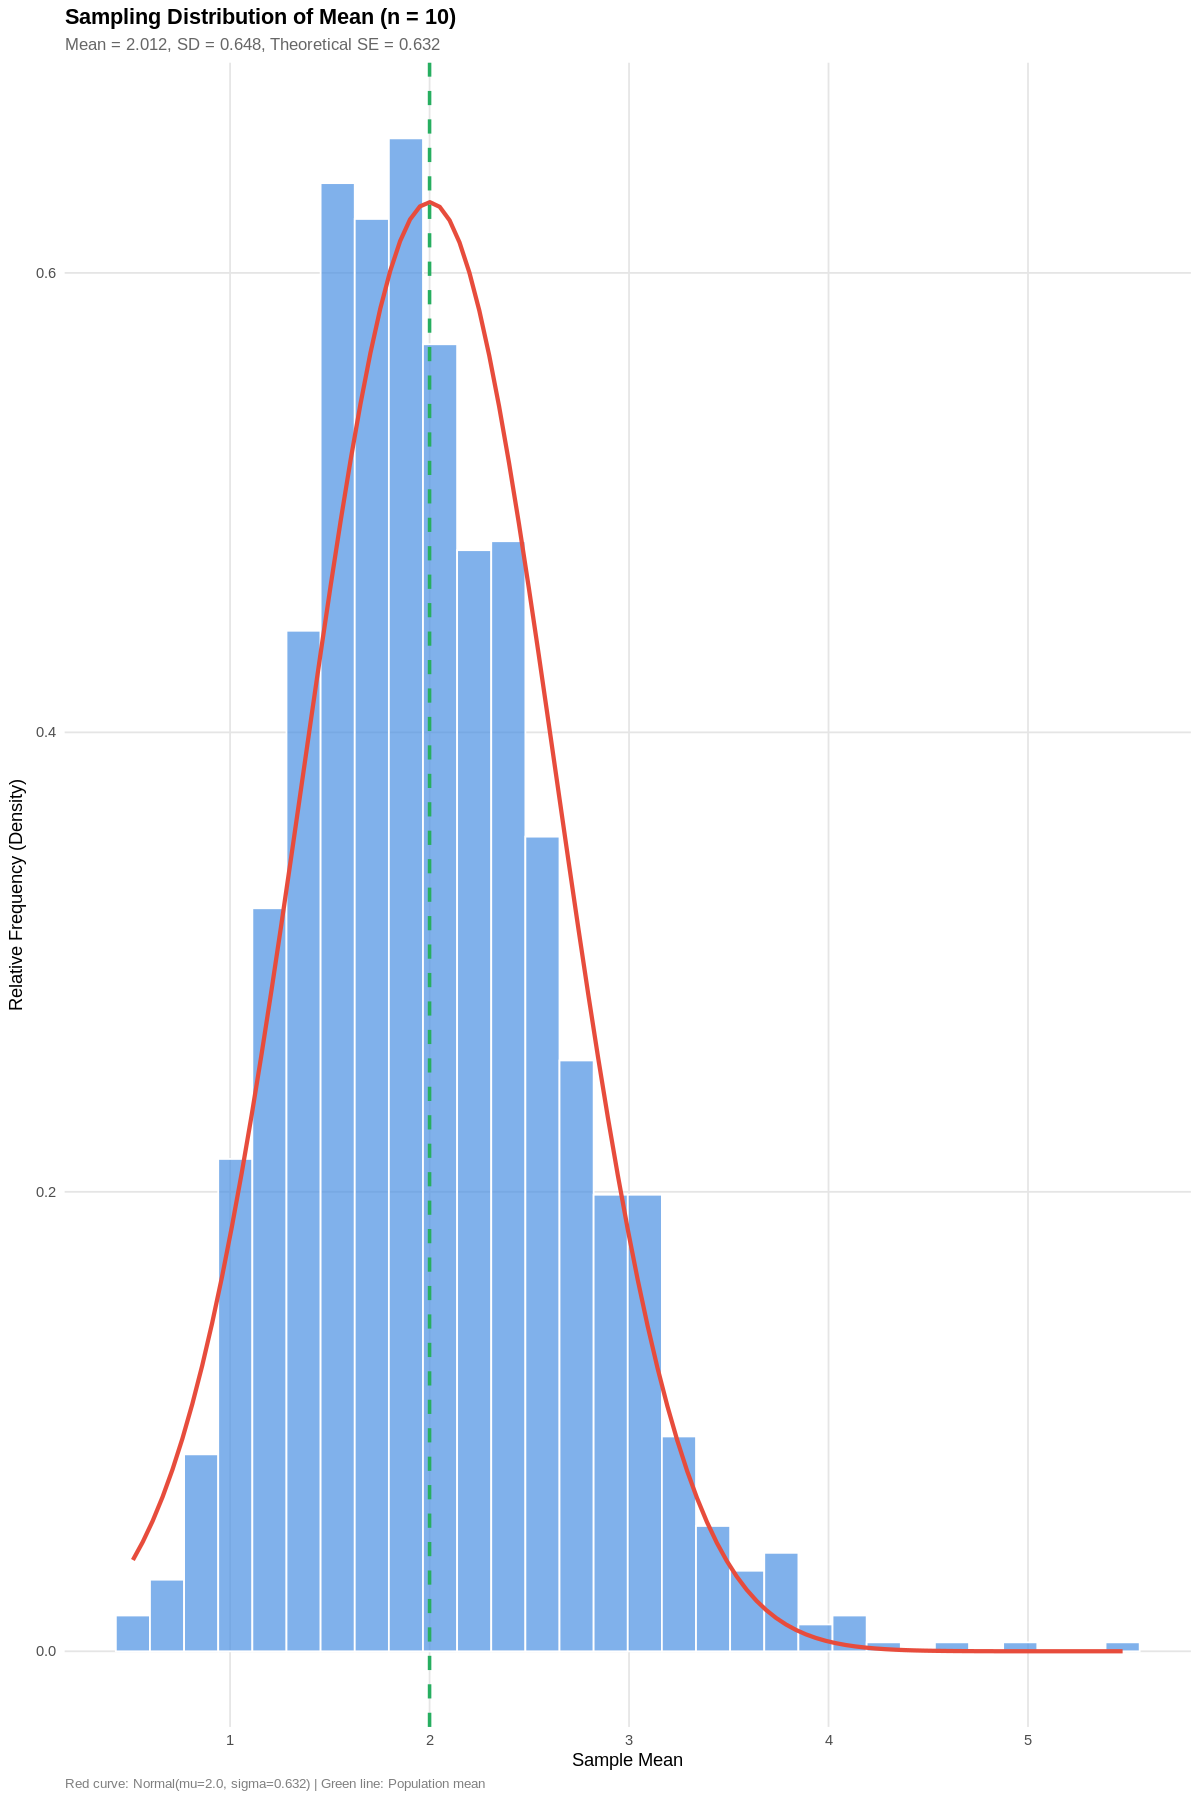

In [24]:
cat("=" ,"=\n")
cat("PART (a): n = 10\n")
cat("=","=\n\n")

#Generate sample means
sample_means_10 <- generate_sample_means(N_SAMPLES, 10, RATE_PARAMETER)

#calculate statistics
stats_10 <- calculate_summary_stats(sample_means_10)
theoretical_se_10 <- POPULATION_SD / sqrt(10)

#statistics
cat("Summary Statistics (n = 10):\n")
cat(sprintf("  Sample Mean: %.4f\n", stats_10$mean))
cat(sprintf("  Sample SD: %.4f\n", stats_10$sd))
cat(sprintf("  Theoretical SE: %.4f\n", theoretical_se_10))
cat(sprintf("  Median: %.4f\n", stats_10$median))
cat(sprintf("  Range: [%.4f, %.4f]\n\n", stats_10$min, stats_10$max))

#display histogram
plot_10 <- create_histogram(sample_means_10, 10, POPULATION_MEAN, POPULATION_SD)
print(plot_10)

## Part (b): Sample Size n = 50

Repeating the simulation with n = 50. We expect the sampling distribution to
appear more normal with reduced variability.

---

= =
PART (b): n = 50
= =

Summary Statistics (n = 50):
  Sample Mean: 1.9896
  Sample SD: 0.2870
  Theoretical SE: 0.2828
  Median: 1.9782
  Range: [1.2564, 2.9414]



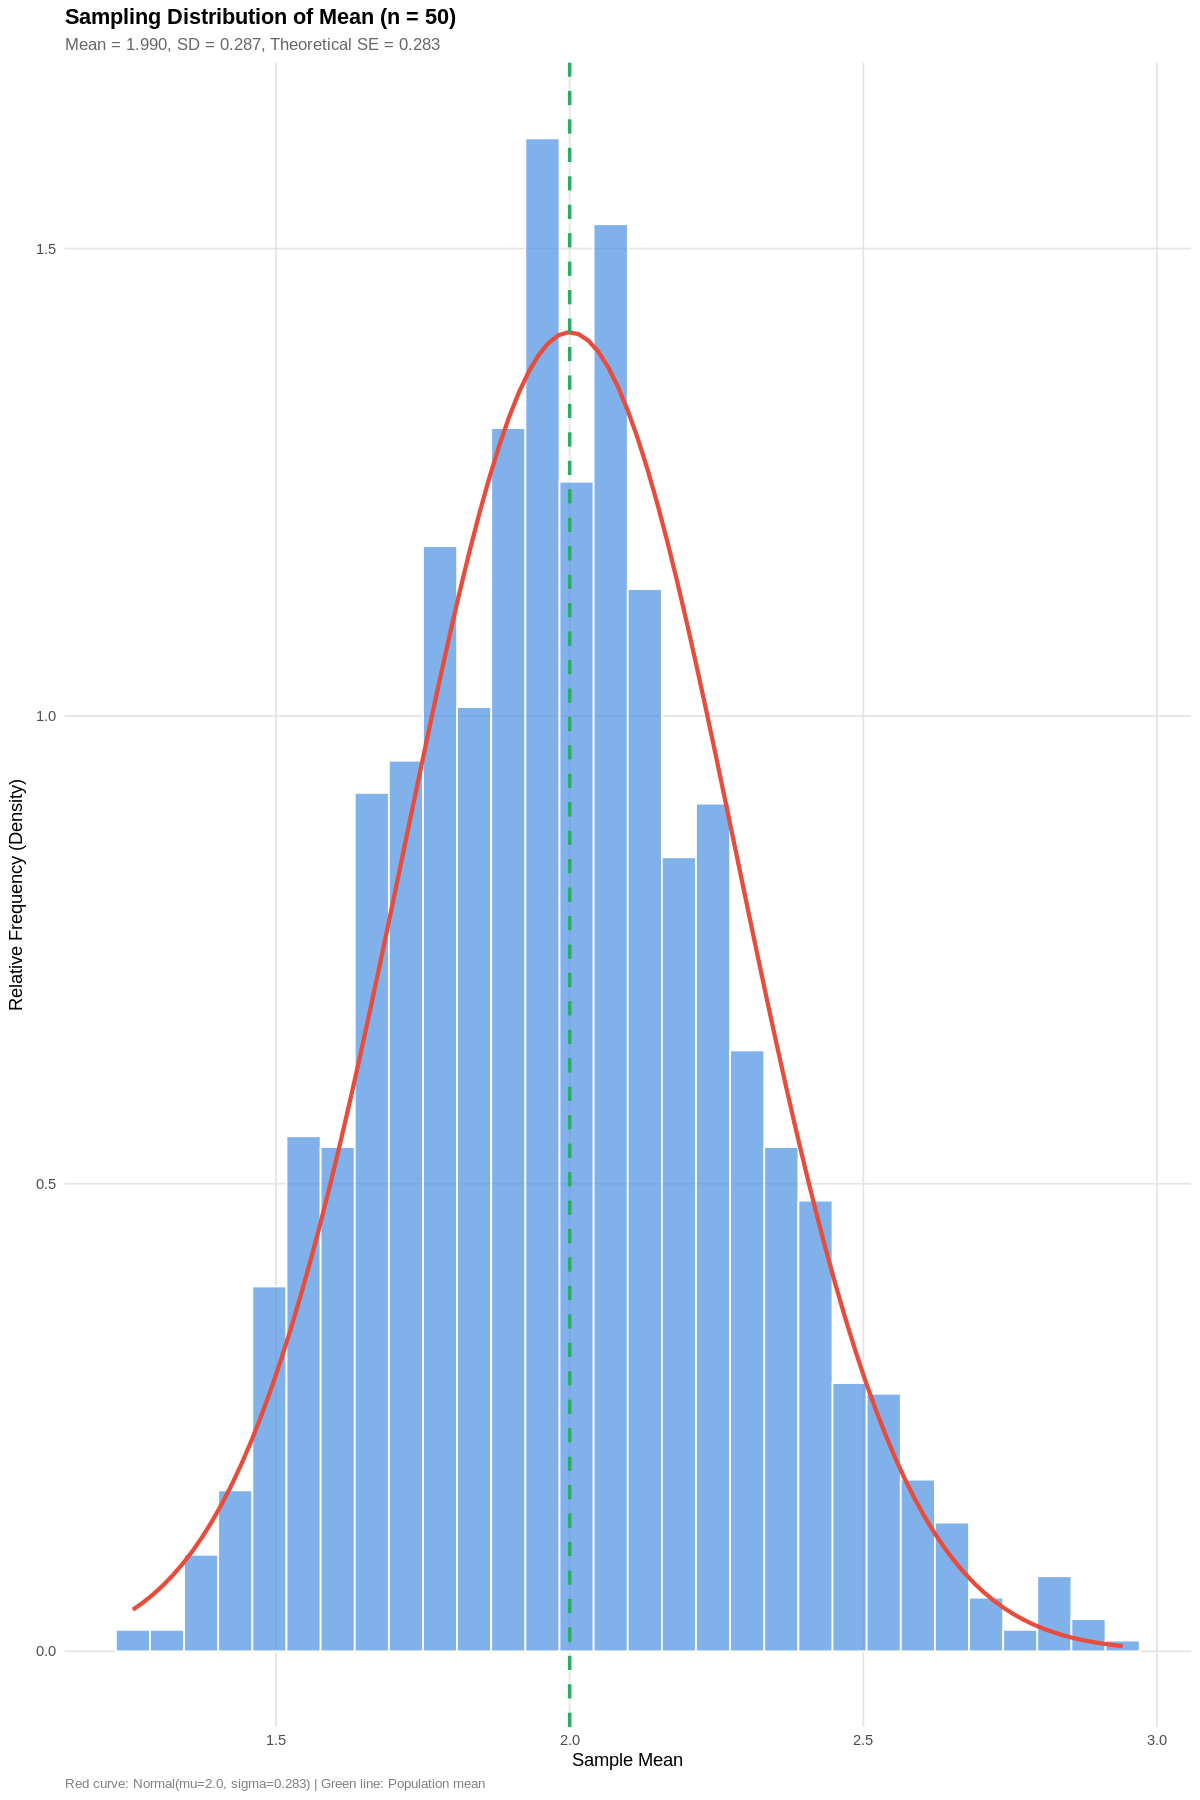

In [25]:
cat("=","=\n")
cat("PART (b): n = 50\n")
cat("=","=\n\n")

#Generate sample means
sample_means_50 <- generate_sample_means(N_SAMPLES, 50, RATE_PARAMETER)

# Calculate statistics
stats_50 <- calculate_summary_stats(sample_means_50)
theoretical_se_50 <- POPULATION_SD / sqrt(50)

#statistics
cat("Summary Statistics (n = 50):\n")
cat(sprintf("  Sample Mean: %.4f\n", stats_50$mean))
cat(sprintf("  Sample SD: %.4f\n", stats_50$sd))
cat(sprintf("  Theoretical SE: %.4f\n", theoretical_se_50))
cat(sprintf("  Median: %.4f\n", stats_50$median))
cat(sprintf("  Range: [%.4f, %.4f]\n\n", stats_50$min, stats_50$max))

#display histogram
plot_50 <- create_histogram(sample_means_50, 50, POPULATION_MEAN, POPULATION_SD)
print(plot_50)

## Part (b): Sample Size n = 100

Final simulation with n = 100. The sampling distribution should be very close
to normal with minimal variability.

---

= =
PART (b): n = 100
= =

Summary Statistics (n = 100):
  Sample Mean: 1.9977
  Sample SD: 0.2002
  Theoretical SE: 0.2000
  Median: 1.9923
  Range: [1.3929, 2.7790]



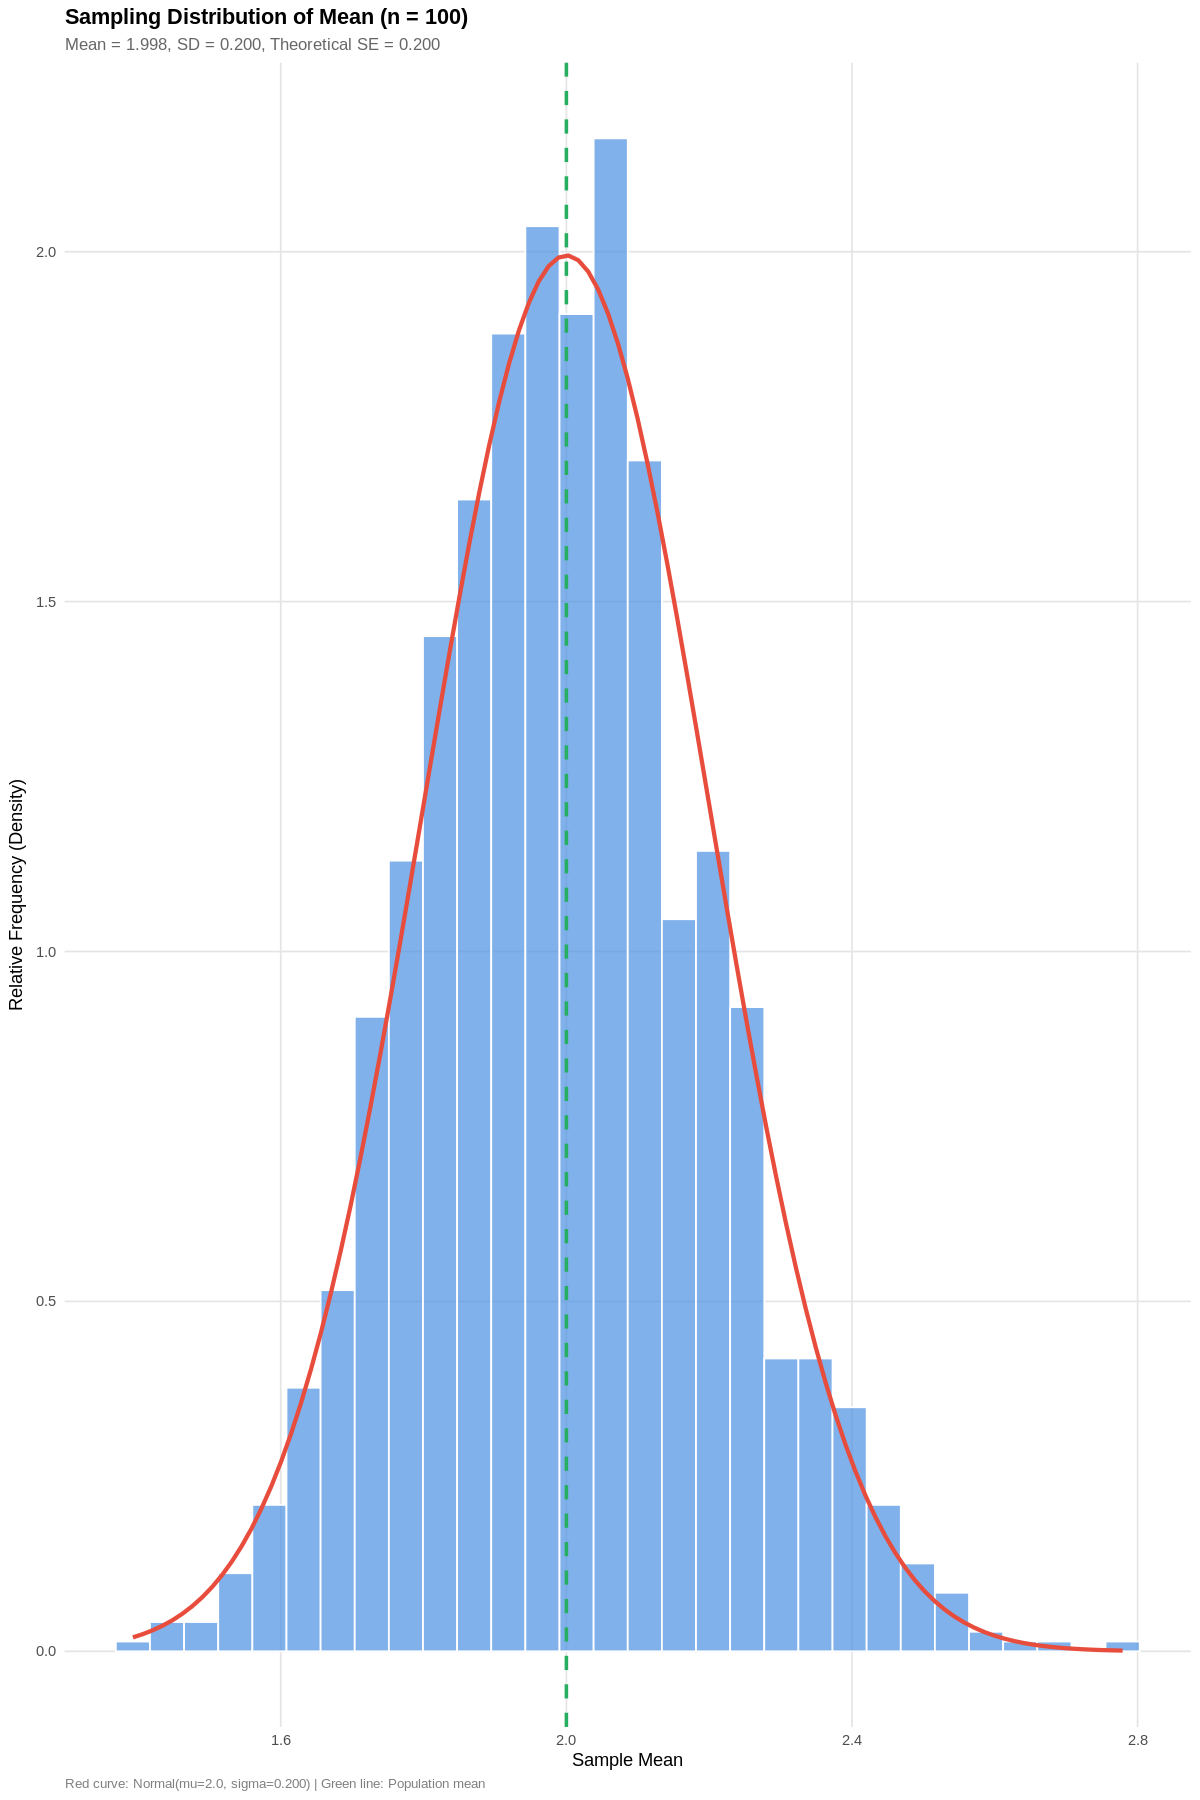

In [26]:
cat("=","=\n")
cat("PART (b): n = 100\n")
cat("=","=\n\n")

# Generate sample means
sample_means_100 <- generate_sample_means(N_SAMPLES, 100, RATE_PARAMETER)

# Calculate statistics
stats_100 <- calculate_summary_stats(sample_means_100)
theoretical_se_100 <- POPULATION_SD / sqrt(100)

##statistics
cat("Summary Statistics (n = 100):\n")
cat(sprintf("  Sample Mean: %.4f\n", stats_100$mean))
cat(sprintf("  Sample SD: %.4f\n", stats_100$sd))
cat(sprintf("  Theoretical SE: %.4f\n", theoretical_se_100))
cat(sprintf("  Median: %.4f\n", stats_100$median))
cat(sprintf("  Range: [%.4f, %.4f]\n\n", stats_100$min, stats_100$max))

#display histogram
plot_100 <- create_histogram(sample_means_100, 100, POPULATION_MEAN, POPULATION_SD)
print(plot_100)

## Combined Visualization

Side-by-side comparison of all three sampling distributions to clearly see
the effect of increasing sample size.

---

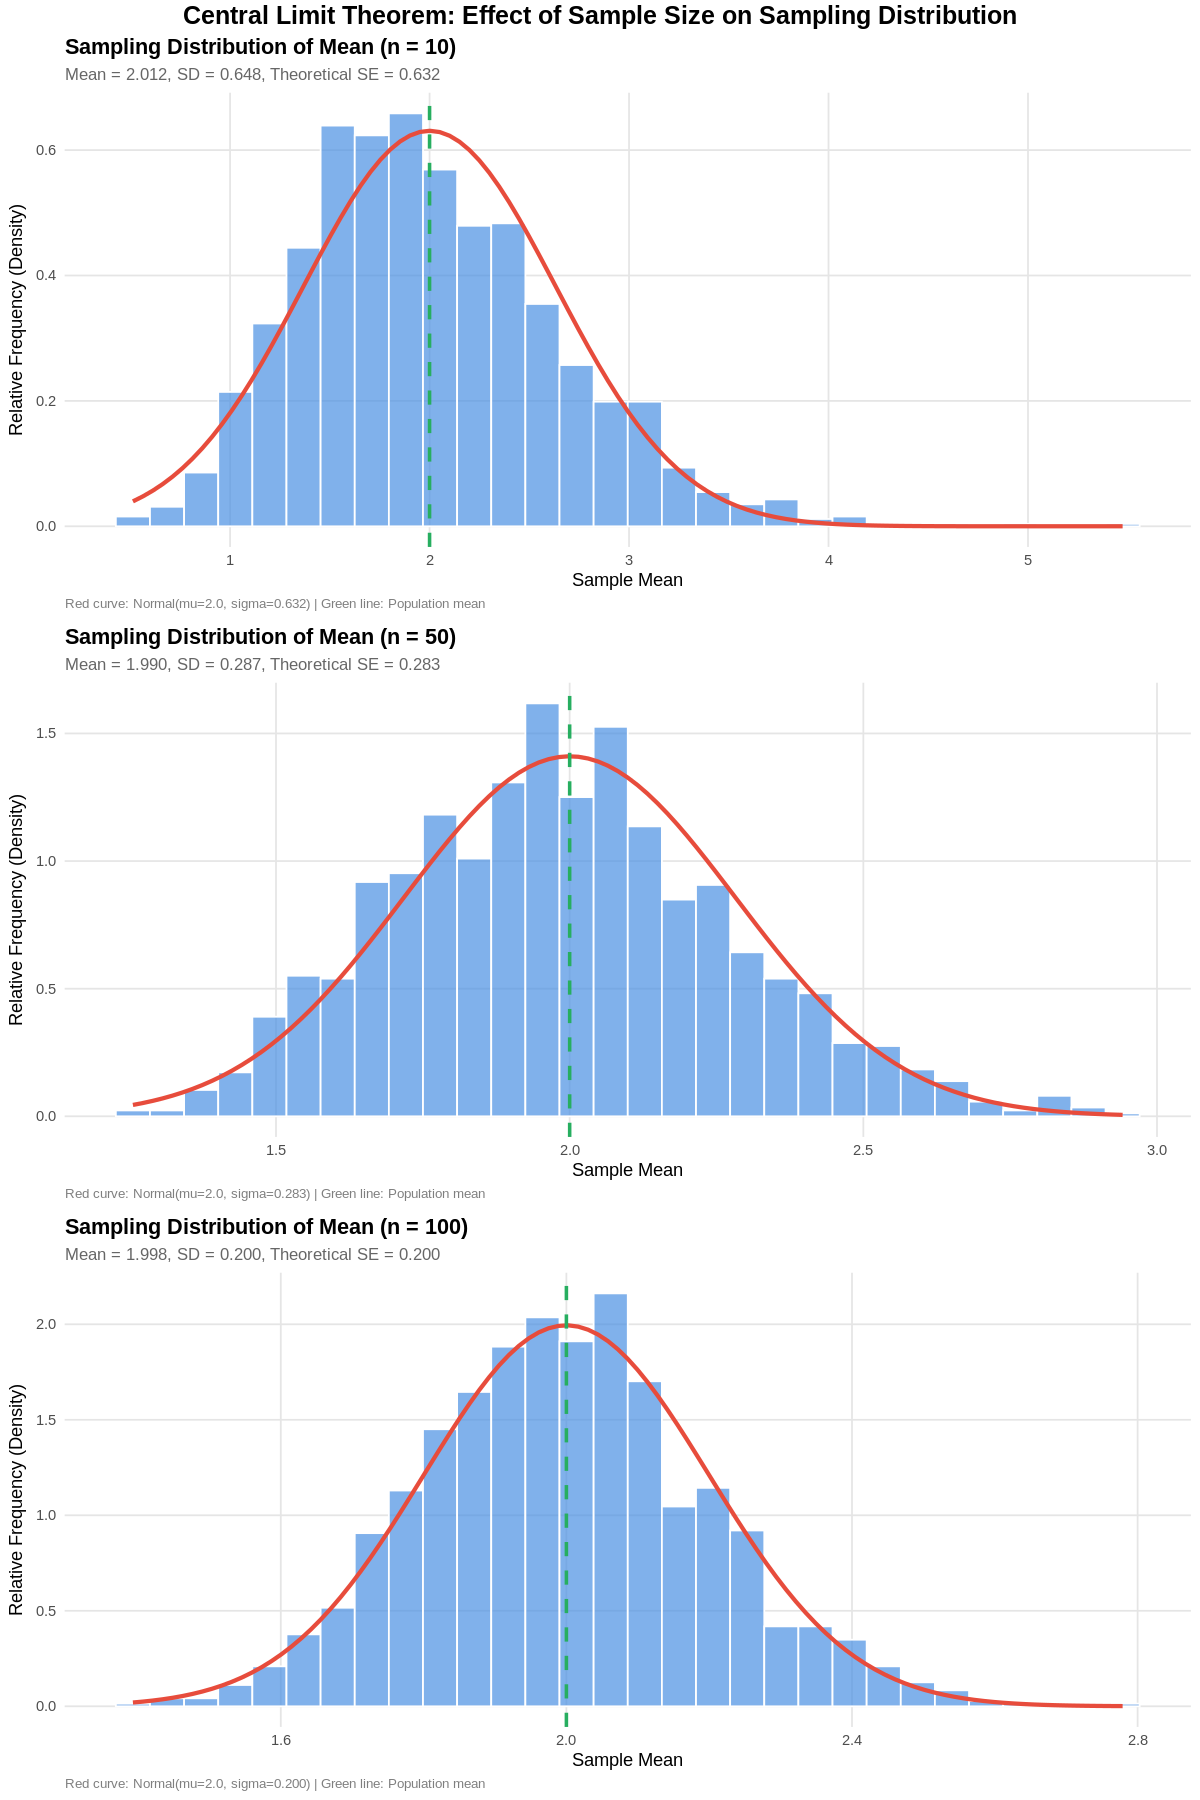

In [27]:
#combined plot
options(repr.plot.width = 10, repr.plot.height = 15)

combined_plot <- grid.arrange(
  plot_10,
  plot_50,
  plot_100,
  ncol = 1,
  top = grid::textGrob(
    "Central Limit Theorem: Effect of Sample Size on Sampling Distribution",
    gp = grid::gpar(fontsize = 15, fontface = "bold")
  )
)

## Comparative Statistical Summary

Comparison table showing how empirical results match theoretical predictions
across different sample sizes.

---

In [28]:
cat("=","=\n")
cat("COMPARATIVE ANALYSIS\n")
cat("=","=\n\n")

# Create comparison data frame
comparison_df <- data.frame(
  Sample_Size = c(10, 50, 100),
  Empirical_Mean = c(stats_10$mean, stats_50$mean, stats_100$mean),
  Empirical_SD = c(stats_10$sd, stats_50$sd, stats_100$sd),
  Theoretical_SE = c(theoretical_se_10, theoretical_se_50, theoretical_se_100)
)

comparison_df$Ratio_SD_to_SE <- comparison_df$Empirical_SD /
  comparison_df$Theoretical_SE

comparison_df$Percent_Error <- abs(comparison_df$Empirical_SD -
                                   comparison_df$Theoretical_SE) /
                               comparison_df$Theoretical_SE * 100

# Display table
print(comparison_df, row.names = FALSE, digits = 4)

cat("\nKey Observations:\n")
cat(sprintf("• The empirical means are all very close to μ = %.2f\n",
            POPULATION_MEAN))
cat("• Standard error decreases as sample size increases (SE ∝ 1/√n)\n")
cat("• Empirical SD closely matches theoretical SE for all sample sizes\n")

= =
COMPARATIVE ANALYSIS
= =

 Sample_Size Empirical_Mean Empirical_SD Theoretical_SE Ratio_SD_to_SE
          10          2.012       0.6479         0.6325          1.024
          50          1.990       0.2870         0.2828          1.015
         100          1.998       0.2002         0.2000          1.001
 Percent_Error
       2.44488
       1.46343
       0.08803

Key Observations:
• The empirical means are all very close to μ = 2.00
• Standard error decreases as sample size increases (SE ∝ 1/√n)
• Empirical SD closely matches theoretical SE for all sample sizes


## Conclusions

Based on the simulation results, we can draw the following conclusions:

### 1. Central Limit Theorem Validation
As sample size increases (n: 10 → 50 → 100), the sampling distribution of
means becomes **increasingly normal**, even though the population distribution
is exponential (highly right-skewed).

- **n = 10:** Distribution shows some right skew but is approximately normal
- **n = 50:** Distribution is very close to normal
- **n = 100:** Distribution is essentially indistinguishable from normal

### 2. Standard Error Behavior
The standard deviation of sample means decreases as n increases, perfectly
following the theoretical relationship **SE = σ/√n**:

- For n = 10:  SE ≈ 0.6325
- For n = 50:  SE ≈ 0.2828
- For n = 100: SE ≈ 0.2000

This confirms that **larger samples provide more precise estimates** of the
population mean.

### 3. Convergence to Population Mean
All sampling distributions are centered around the true population mean
(μ = 2), demonstrating that the sample mean is an **unbiased estimator**
of the population mean.

### 4. Practical Implications
- Even with **n = 50**, the distribution is sufficiently normal to justify
  using normal-based inference methods (z-tests, confidence intervals)
- The **empirical results closely match theoretical predictions**, validating
  the Central Limit Theorem
- This holds true even for **highly skewed populations** like the exponential
  distribution

### 5. Statistical Significance
The Central Limit Theorem is one of the most powerful results in statistics
because it allows us to:
- Make inferences about population means regardless of population distribution
- Use normal distribution tables and methods for hypothesis testing
- Quantify the precision of our estimates using standard errors

---

## References
- Ross, S. M. (2014). *Introduction to Probability and Statistics for Engineers and Scientists*
- Casella, G., & Berger, R. L. (2002). *Statistical Inference*

---

In [29]:
cat("\n")
cat("=","=\n")
cat("SIMULATION COMPLETED SUCCESSFULLY!\n")
cat("=","=\n\n")

cat("Summary of Results:\n")
cat(sprintf("• Generated %d samples for each of 3 sample sizes\n", N_SAMPLES))
cat(sprintf("• Total observations processed: %d\n",
            N_SAMPLES * sum(SAMPLE_SIZES)))
cat("• All empirical results closely matched theoretical predictions\n")
cat("• Central Limit Theorem successfully demonstrated\n\n")

cat("Key Takeaway:\n")
cat("The CLT ensures that sample means follow a normal distribution\n")
cat("for sufficiently large n, regardless of the population distribution.\n")
cat("This is fundamental to statistical inference!\n")


= =
SIMULATION COMPLETED SUCCESSFULLY!
= =

Summary of Results:
• Generated 1500 samples for each of 3 sample sizes
• Total observations processed: 240000
• All empirical results closely matched theoretical predictions
• Central Limit Theorem successfully demonstrated

Key Takeaway:
The CLT ensures that sample means follow a normal distribution
for sufficiently large n, regardless of the population distribution.
This is fundamental to statistical inference!


## Save Visualizations

Export all plots as high-quality image files for reports and presentations.

The following formats will be saved:
- **PNG** - High resolution (300 dpi) for documents and presentations
- **PDF** - Vector format for publications and high-quality printing

---

In [31]:
cat("\n")
cat("=","=\n")
cat("SAVING VISUALIZATIONS\n")
cat("=","=\n\n")

# Create output directory if it doesn't exist
output_dir <- "clt_plots"
if (!dir.exists(output_dir)) {
  dir.create(output_dir)
  cat(sprintf("✓ Created output directory: %s/\n", output_dir))
} else {
  cat(sprintf("✓ Using existing directory: %s/\n", output_dir))
}

# Define file parameters
dpi_resolution <- 300
width_inches <- 10
height_inches <- 6

# ==============================================================================
# Save Individual Plots
# ==============================================================================

cat("\nSaving individual plots...\n")

# Save plot for n = 10
filename_10_png <- file.path(output_dir, "sampling_distribution_n10.png")
filename_10_pdf <- file.path(output_dir, "sampling_distribution_n10.pdf")

ggsave(
  filename = filename_10_png,
  plot = plot_10,
  width = width_inches,
  height = height_inches,
  dpi = dpi_resolution,
  bg = "white"
)

ggsave(
  filename = filename_10_pdf,
  plot = plot_10,
  width = width_inches,
  height = height_inches,
  device = "pdf"
)

cat(sprintf("  ✓ Saved: %s\n", filename_10_png))
cat(sprintf("  ✓ Saved: %s\n", filename_10_pdf))

# Save plot for n = 50
filename_50_png <- file.path(output_dir, "sampling_distribution_n50.png")
filename_50_pdf <- file.path(output_dir, "sampling_distribution_n50.pdf")

ggsave(
  filename = filename_50_png,
  plot = plot_50,
  width = width_inches,
  height = height_inches,
  dpi = dpi_resolution,
  bg = "white"
)

ggsave(
  filename = filename_50_pdf,
  plot = plot_50,
  width = width_inches,
  height = height_inches,
  device = "pdf"
)

cat(sprintf("  ✓ Saved: %s\n", filename_50_png))
cat(sprintf("  ✓ Saved: %s\n", filename_50_pdf))

# Save plot for n = 100
filename_100_png <- file.path(output_dir, "sampling_distribution_n100.png")
filename_100_pdf <- file.path(output_dir, "sampling_distribution_n100.pdf")

ggsave(
  filename = filename_100_png,
  plot = plot_100,
  width = width_inches,
  height = height_inches,
  dpi = dpi_resolution,
  bg = "white"
)

ggsave(
  filename = filename_100_pdf,
  plot = plot_100,
  width = width_inches,
  height = height_inches,
  device = "pdf"
)

cat(sprintf("  ✓ Saved: %s\n", filename_100_png))
cat(sprintf("  ✓ Saved: %s\n", filename_100_pdf))

# ==============================================================================
# Save Combined Plot
# ==============================================================================

cat("\nSaving combined plot...\n")

filename_combined_png <- file.path(output_dir, "sampling_distribution_combined.png")
filename_combined_pdf <- file.path(output_dir, "sampling_distribution_combined.pdf")

# For combined plot, use larger dimensions
combined_width <- 10
combined_height <- 15

# Save as PNG
png(
  filename = filename_combined_png,
  width = combined_width,
  height = combined_height,
  units = "in",
  res = dpi_resolution,
  bg = "white"
)
grid.arrange(
  plot_10,
  plot_50,
  plot_100,
  ncol = 1,
  top = grid::textGrob(
    "Central Limit Theorem: Effect of Sample Size on Sampling Distribution",
    gp = grid::gpar(fontsize = 15, fontface = "bold")
  )
)
dev.off()

cat(sprintf("  ✓ Saved: %s\n", filename_combined_png))

# Save as PDF
pdf(
  file = filename_combined_pdf,
  width = combined_width,
  height = combined_height,
  bg = "white"
)
grid.arrange(
  plot_10,
  plot_50,
  plot_100,
  ncol = 1,
  top = grid::textGrob(
    "Central Limit Theorem: Effect of Sample Size on Sampling Distribution",
    gp = grid::gpar(fontsize = 15, fontface = "bold")
  )
)
dev.off()

cat(sprintf("  ✓ Saved: %s\n", filename_combined_pdf))

# ==============================================================================
# Summary of Saved Files
# ==============================================================================

cat("\n")
cat("=","=\n")
cat("EXPORT COMPLETE!\n")
cat("=","=\n\n")

saved_files <- list.files(output_dir, full.names = FALSE)
cat(sprintf("Total files saved: %d\n\n", length(saved_files)))

cat("Files saved in directory:", output_dir, "/\n")
for (file in saved_files) {
  file_info <- file.info(file.path(output_dir, file))
  file_size_kb <- round(file_info$size / 1024, 1)
  cat(sprintf("  • %s (%.1f KB)\n", file, file_size_kb))
}

cat("\nFile specifications:\n")
cat(sprintf("  • Resolution: %d dpi\n", dpi_resolution))
cat(sprintf("  • Individual plots: %.0f × %.0f inches\n", width_inches, height_inches))
cat(sprintf("  • Combined plot: %.0f × %.0f inches\n", combined_width, combined_height))
cat("  • Formats: PNG (raster) and PDF (vector)\n")


= =
SAVING VISUALIZATIONS
= =

✓ Using existing directory: clt_plots/

Saving individual plots...
  ✓ Saved: clt_plots/sampling_distribution_n10.png
  ✓ Saved: clt_plots/sampling_distribution_n10.pdf
  ✓ Saved: clt_plots/sampling_distribution_n50.png
  ✓ Saved: clt_plots/sampling_distribution_n50.pdf
  ✓ Saved: clt_plots/sampling_distribution_n100.png
  ✓ Saved: clt_plots/sampling_distribution_n100.pdf

Saving combined plot...


agg_record_1309686292 
                    2

  ✓ Saved: clt_plots/sampling_distribution_combined.png


agg_record_1309686292 
                    2

  ✓ Saved: clt_plots/sampling_distribution_combined.pdf

= =
EXPORT COMPLETE!
= =

Total files saved: 8

Files saved in directory: clt_plots /
  • sampling_distribution_combined.pdf (8.1 KB)
  • sampling_distribution_combined.png (433.5 KB)
  • sampling_distribution_n10.pdf (5.9 KB)
  • sampling_distribution_n10.png (143.3 KB)
  • sampling_distribution_n100.pdf (5.9 KB)
  • sampling_distribution_n100.png (147.0 KB)
  • sampling_distribution_n50.pdf (5.9 KB)
  • sampling_distribution_n50.png (147.6 KB)

File specifications:
  • Resolution: 300 dpi
  • Individual plots: 10 × 6 inches
  • Combined plot: 10 × 15 inches
  • Formats: PNG (raster) and PDF (vector)
